# 02 Model Training (Stronger Workflow)
This notebook now follows a stronger decision flow:
1. Quantile feature screening (fixed alpha) -> alpha tuning -> lock baseline
2. Expanded LightGBM feature screening (fixed params, 2-stage race)
3. Tune winner with Optuna (more trials + early stopping)
4. Test check (baseline + tuned winner) + SHAP summary
5. Final backtest with out-of-time recent-fold gate + promotion decision


In [1]:
import sys
from contextlib import nullcontext
from pathlib import Path

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import lightgbm as lgb

from lightgbm import LGBMRegressor
from scipy.stats import ttest_rel, wilcoxon
from sklearn.linear_model import QuantileRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    import optuna
    from optuna.trial import TrialState
    OPTUNA_AVAILABLE = True
except Exception:
    optuna = None
    TrialState = None
    OPTUNA_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    shap = None
    SHAP_AVAILABLE = False

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.reproducibility import set_global_seed


In [2]:
# Load config
params_path = PROJECT_ROOT / "params.yaml"
dvc_path = PROJECT_ROOT / "dvc.yaml"

params = yaml.safe_load(params_path.read_text(encoding="utf-8"))
dvc_cfg = yaml.safe_load(dvc_path.read_text(encoding="utf-8"))
cfg = params["model_training"]

# DVC/params coherence
if dvc_cfg["stages"]["validate_data"]["outs"][0] != "${validation.output_path}":
    raise ValueError("Unexpected validate_data output in dvc.yaml")
if cfg["input_path"] != params["validation"]["output_path"]:
    raise ValueError("model_training.input_path must equal validation.output_path")

SEED = int(params["global"]["seed"])
set_global_seed(SEED)

# Baseline and gates
benchmark_cfg = cfg.get("benchmark", {})
LOCKED_BENCHMARK_BASELINE = str(benchmark_cfg.get("locked_baseline", "quantile_lag24_lag168_hour_dow"))
BACKTEST_N_SPLITS = int(cfg.get("backtest", {}).get("n_splits", 5))
COVERAGE_TOLERANCE = float(cfg.get("backtest", {}).get("coverage_tolerance", 0.05))
MAX_CROSSING_RATE = float(cfg.get("backtest", {}).get("max_crossing_rate", 0.0))

baseline_tune_cfg = benchmark_cfg.get("tune", {})
BASELINE_TUNE_ENABLED = bool(baseline_tune_cfg.get("enabled", True))
BASELINE_TUNE_CANDIDATES_CFG = list(baseline_tune_cfg.get("candidates", []))
BASELINE_ALPHA_GRID = sorted(float(a) for a in baseline_tune_cfg.get("alpha_grid", [0.001, 0.01, 0.05, 0.1]))
BASELINE_TUNE_CV_SPLITS = int(baseline_tune_cfg.get("cv_splits", BACKTEST_N_SPLITS))

# LightGBM race+tuning settings
lightgbm_tuning_cfg = cfg.get("lightgbm_tuning", {})
TUNING_ENABLED = bool(lightgbm_tuning_cfg.get("enabled", True))
TUNING_CANDIDATES_CFG = list(lightgbm_tuning_cfg.get("candidates", []))
RACE_CV_SPLITS = int(lightgbm_tuning_cfg.get("race_cv_splits", 5))
RACE_TOP_K = int(lightgbm_tuning_cfg.get("race_top_k", 4))
USE_FULL_TRAIN_IF_SMALL = bool(lightgbm_tuning_cfg.get("use_full_train_if_small", True))
SMALL_DATA_THRESHOLD = int(lightgbm_tuning_cfg.get("small_data_threshold", 30000))
TUNING_FRACTION_MAX_ROWS = int(lightgbm_tuning_cfg.get("fraction", {}).get("max_train_rows", 5000))

TUNING_CV_SPLITS = int(lightgbm_tuning_cfg.get("fraction", {}).get("cv_splits", RACE_CV_SPLITS))
USE_FULL_DATA_FOR_TUNING = bool(lightgbm_tuning_cfg.get("use_full_data_for_tuning", True))
OPTUNA_TRIALS = int(lightgbm_tuning_cfg.get("optuna_trials", 30))
EARLY_STOPPING_ROUNDS = int(lightgbm_tuning_cfg.get("early_stopping_rounds", 50))
SIGNIFICANCE_ALPHA = float(lightgbm_tuning_cfg.get("significance_alpha", 0.05))
OUT_OF_TIME_RECENT_SPLITS = int(lightgbm_tuning_cfg.get("out_of_time_recent_splits", 2))
SHAP_SAMPLE_SIZE = int(lightgbm_tuning_cfg.get("shap_sample_size", 500))

MIN_IMPROVEMENT_PCT = float(lightgbm_tuning_cfg.get("min_improvement_pct", 0.03))
TUNING_RANDOM_STATE = int(lightgbm_tuning_cfg.get("random_state", SEED))
TUNING_SEARCH_SPACE = lightgbm_tuning_cfg.get("search_space", {})

# MLflow
mlflow_cfg = cfg.get("mlflow", {})
MLFLOW_ENABLED = bool(mlflow_cfg.get("enabled", True))
MLFLOW_TRACKING_URI = str(PROJECT_ROOT / mlflow_cfg.get("tracking_uri", "mlruns"))
EXPERIMENTS = {
    "benchmark": mlflow_cfg.get("quantile_lag_time_experiment", "quantile_regression_lag24_lag168_hour_dow"),
    "tuning": mlflow_cfg.get("lightgbm_tuning_experiment", "lightgbm_quantile_tuning"),
}
if MLFLOW_ENABLED:
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

print(f"Seed: {SEED}")
print(f"Locked benchmark baseline (starting point): {LOCKED_BENCHMARK_BASELINE}")
print(f"Baseline tune -> enabled={BASELINE_TUNE_ENABLED}, cv={BASELINE_TUNE_CV_SPLITS}, alpha_grid={BASELINE_ALPHA_GRID}")
print(f"MLflow enabled: {MLFLOW_ENABLED} | tracking URI: {MLFLOW_TRACKING_URI}")
print(f"Race config -> cv={RACE_CV_SPLITS}, top_k={RACE_TOP_K}, full_train_if_small={USE_FULL_TRAIN_IF_SMALL}")
print(f"Tuning config -> optuna_trials={OPTUNA_TRIALS}, cv={TUNING_CV_SPLITS}, early_stopping={EARLY_STOPPING_ROUNDS}")
print(f"Validation config -> significance_alpha={SIGNIFICANCE_ALPHA}, oot_recent_splits={OUT_OF_TIME_RECENT_SPLITS}")
print(f"Optuna available: {OPTUNA_AVAILABLE} | SHAP available: {SHAP_AVAILABLE}")


Seed: 42
Locked benchmark baseline (starting point): quantile_lag24_lag168_hour_dow
Baseline tune -> enabled=True, cv=3, alpha_grid=[0.001, 0.01, 0.1, 0.3]
MLflow enabled: True | tracking URI: /home/nilima/Desktop/portfolio/probabilistic-energy-forecasting-ML/mlruns
Race config -> cv=5, top_k=4, full_train_if_small=True
Tuning config -> optuna_trials=30, cv=5, early_stopping=50
Validation config -> significance_alpha=0.05, oot_recent_splits=2
Optuna available: True | SHAP available: True


In [3]:
# Load data and build leakage-safe features
input_path = PROJECT_ROOT / cfg["input_path"]
df_data = pd.read_parquet(input_path).sort_values(cfg["time_col"]).reset_index(drop=True)

TARGET_COL = cfg["target_col"]
TIME_COL = cfg["time_col"]
LAG_HOURS = [int(v) for v in cfg["lags_hours"]]
BASE_FEATURE_COLS = [f"lag_{h}" for h in LAG_HOURS]

QUANTILES = sorted(float(q) for q in cfg["quantiles"])
Q_LOW, Q_MED, Q_HIGH = QUANTILES[0], QUANTILES[len(QUANTILES)//2], QUANTILES[-1]
NOMINAL_COVERAGE = Q_HIGH - Q_LOW
MIN_FOLD_COVERAGE = float(cfg.get("backtest", {}).get("min_fold_coverage", NOMINAL_COVERAGE - COVERAGE_TOLERANCE))

work_df = df_data.copy()
for lag_h, lag_col in zip(LAG_HOURS, BASE_FEATURE_COLS):
    work_df[lag_col] = work_df[TARGET_COL].shift(lag_h)
work_df["day_of_week"] = work_df[TIME_COL].dt.dayofweek
work_df["hour"] = work_df[TIME_COL].dt.hour
work_df["is_weekend"] = (work_df["day_of_week"] >= 5).astype(int)
work_df["month"] = work_df[TIME_COL].dt.month.astype(int)
season_map = {12: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2, 8: 2, 9: 3, 10: 3, 11: 3}
work_df["season_bucket"] = work_df["month"].map(season_map).astype(int)

# lagged generation features only (leakage-safe)
generation_feature_candidates = list(cfg.get("generation_features", []))
GENERATION_BASE_FEATURES = [
    c for c in generation_feature_candidates
    if c in work_df.columns and not work_df[c].isna().all()
]
GENERATION_LAG_HOURS = [int(v) for v in cfg.get("generation_lag_hours", LAG_HOURS)]
GENERATION_LAGGED_FEATURES = []
for base_col in GENERATION_BASE_FEATURES:
    for lag_h in GENERATION_LAG_HOURS:
        lag_col = f"{base_col}_lag_{lag_h}"
        work_df[lag_col] = work_df[base_col].shift(lag_h)
        GENERATION_LAGGED_FEATURES.append(lag_col)

required_feature_cols = BASE_FEATURE_COLS + GENERATION_LAGGED_FEATURES
work_df = work_df.dropna(subset=required_feature_cols).copy()

train_fraction = float(cfg["split"]["train_fraction"])
split_idx = int(len(work_df) * train_fraction)
train_df = work_df.iloc[:split_idx].copy()
test_df = work_df.iloc[split_idx:].copy()

y_train = train_df[TARGET_COL]
y_test = test_df[TARGET_COL]

TARGET_LOWER_BOUND = float(train_df[TARGET_COL].min())
TARGET_UPPER_BOUND = float(train_df[TARGET_COL].max())

gen_lag_24 = sorted([c for c in GENERATION_LAGGED_FEATURES if c.endswith("_lag_24")])
gen_core_tokens = ("photovoltaics", "wind_onshore", "lignite", "fossil_gas", "hard_coal")
gen_core = sorted([c for c in GENERATION_LAGGED_FEATURES if any(tok in c for tok in gen_core_tokens)])

FEATURE_MAP = {
    "quantile_lag24_lag168": ["lag_24", "lag_168"],
    "quantile_lag24_lag168_hour_dow": ["lag_24", "lag_168", "day_of_week", "hour"],
    "quantile_lag24_lag168_hour_dow_weekend": ["lag_24", "lag_168", "day_of_week", "hour", "is_weekend"],
    "quantile_lag24_lag168_hour_dow_gen": ["lag_24", "lag_168", "day_of_week", "hour"] + GENERATION_LAGGED_FEATURES,
    "quantile_lag24_lag168_hour_dow_weekend_gen": ["lag_24", "lag_168", "day_of_week", "hour", "is_weekend"] + GENERATION_LAGGED_FEATURES,
    "quantile_lag24_lag168_hour_dow_weekend_season": ["lag_24", "lag_168", "day_of_week", "hour", "is_weekend", "season_bucket"],
    "quantile_lag24_lag168_hour_dow_weekend_season_gen": ["lag_24", "lag_168", "day_of_week", "hour", "is_weekend", "season_bucket"] + GENERATION_LAGGED_FEATURES,
    "lgbm_lag_only": ["lag_24", "lag_168"],
    "lgbm_lag_time": ["lag_24", "lag_168", "day_of_week", "hour"],
    "lgbm_lag_time_weekend": ["lag_24", "lag_168", "day_of_week", "hour", "is_weekend"],
    "lgbm_lag_time_season": ["lag_24", "lag_168", "day_of_week", "hour", "season_bucket"],
    "lgbm_lag_time_gen_core": ["lag_24", "lag_168", "day_of_week", "hour"] + gen_core,
    "lgbm_lag_time_gen": ["lag_24", "lag_168", "day_of_week", "hour"] + GENERATION_LAGGED_FEATURES,
}

for key, cols in FEATURE_MAP.items():
    FEATURE_MAP[key] = list(dict.fromkeys([c for c in cols if c in work_df.columns]))

default_candidates = [
    "lgbm_lag_only",
    "lgbm_lag_time",
    "lgbm_lag_time_weekend",
    "lgbm_lag_time_season",
    "lgbm_lag_time_gen_core",
    "lgbm_lag_time_gen",
]

if TUNING_CANDIDATES_CFG:
    TUNING_CANDIDATES = [c for c in TUNING_CANDIDATES_CFG if c in FEATURE_MAP]
else:
    TUNING_CANDIDATES = [c for c in default_candidates if c in FEATURE_MAP]

if len(TUNING_CANDIDATES) < 2:
    raise ValueError("Need at least 2 valid LightGBM candidates for race")

default_baseline_candidates = [
    "quantile_lag24_lag168",
    "quantile_lag24_lag168_hour_dow",
    "quantile_lag24_lag168_hour_dow_weekend",
    "quantile_lag24_lag168_hour_dow_gen",
    "quantile_lag24_lag168_hour_dow_weekend_gen",
    "quantile_lag24_lag168_hour_dow_weekend_season",
    "quantile_lag24_lag168_hour_dow_weekend_season_gen",
]
if BASELINE_TUNE_CANDIDATES_CFG:
    BASELINE_CANDIDATES = [c for c in BASELINE_TUNE_CANDIDATES_CFG if c in FEATURE_MAP]
else:
    BASELINE_CANDIDATES = [c for c in default_baseline_candidates if c in FEATURE_MAP]

if LOCKED_BENCHMARK_BASELINE in FEATURE_MAP and LOCKED_BENCHMARK_BASELINE not in BASELINE_CANDIDATES:
    BASELINE_CANDIDATES.append(LOCKED_BENCHMARK_BASELINE)

if not BASELINE_CANDIDATES:
    raise ValueError("No valid quantile baseline candidates found")

print(f"Rows: {len(work_df):,} | Train: {len(train_df):,} | Test: {len(test_df):,}")
print("Generation lagged features:", len(GENERATION_LAGGED_FEATURES))
print(f"Target bounds from train: [{TARGET_LOWER_BOUND:.2f}, {TARGET_UPPER_BOUND:.2f}]")
print(f"Gate min fold coverage: {MIN_FOLD_COVERAGE:.3f}")
print(f"Baseline candidates ({len(BASELINE_CANDIDATES)}): {BASELINE_CANDIDATES}")
print(f"Race candidates ({len(TUNING_CANDIDATES)}): {TUNING_CANDIDATES}")


Rows: 17,376 | Train: 13,900 | Test: 3,476
Generation lagged features: 12
Target bounds from train: [-8443.14, 67890.25]
Gate min fold coverage: 0.700
Baseline candidates (7): ['quantile_lag24_lag168', 'quantile_lag24_lag168_hour_dow', 'quantile_lag24_lag168_hour_dow_weekend', 'quantile_lag24_lag168_hour_dow_gen', 'quantile_lag24_lag168_hour_dow_weekend_gen', 'quantile_lag24_lag168_hour_dow_weekend_season', 'quantile_lag24_lag168_hour_dow_weekend_season_gen']
Race candidates (6): ['lgbm_lag_only', 'lgbm_lag_time', 'lgbm_lag_time_weekend', 'lgbm_lag_time_season', 'lgbm_lag_time_gen_core', 'lgbm_lag_time_gen']


In [4]:
# Helpers

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def pinball_loss(y_true, y_pred, q):
    residual = y_true - y_pred
    return float(np.where(residual >= 0, q * residual, (q - 1) * residual).mean())


def enforce_quantile_order(pred_map):
    ordered = np.sort(np.column_stack([pred_map[q] for q in QUANTILES]), axis=1)
    return {q: ordered[:, i] for i, q in enumerate(QUANTILES)}


def apply_domain_bounds(pred_map):
    return {q: np.clip(np.asarray(pred_map[q]), TARGET_LOWER_BOUND, TARGET_UPPER_BOUND) for q in QUANTILES}


def interval_metrics(pred_map, y_true):
    coverage = float(((pred_map[Q_LOW] <= y_true) & (y_true <= pred_map[Q_HIGH])).mean())
    width = float((pred_map[Q_HIGH] - pred_map[Q_LOW]).mean())
    return {"coverage": coverage, "interval_width": width}


def quantile_crossing_rate(pred_map):
    q_matrix = np.column_stack([pred_map[q] for q in QUANTILES])
    return float((np.diff(q_matrix, axis=1) < 0).any(axis=1).mean())


def split_proper_calibration(df, frac):
    calib_size = int(round(len(df) * frac))
    calib_size = min(max(calib_size, 1), len(df) - 1)
    return df.iloc[:-calib_size].copy(), df.iloc[-calib_size:].copy()


def conformal_qhat(y_true, pred_low, pred_high, alpha):
    scores = np.maximum(pred_low - y_true, y_true - pred_high)
    n = len(scores)
    q_level = min(1.0, np.ceil((n + 1) * (1 - alpha)) / n)
    return float(max(0.0, np.quantile(scores, q_level, method="higher")))


def apply_conformal_interval(pred_map, qhat):
    adjusted = {q: np.asarray(pred_map[q]).copy() for q in QUANTILES}
    adjusted[Q_LOW] -= qhat
    adjusted[Q_HIGH] += qhat
    return enforce_quantile_order(adjusted)


def summarize_fold_metrics(fold_df):
    metric_cols = [
        "pinball_q10", "pinball_q50", "pinball_q90", "pinball_mean",
        "mae_p50", "rmse_p50", "r2_p50", "coverage", "interval_width",
        "coverage_gap", "crossing_rate",
    ]
    out = {}
    for col in metric_cols:
        out[f"{col}_mean"] = float(fold_df[col].mean())
        out[f"{col}_std"] = float(fold_df[col].std(ddof=0))
    out["coverage_min"] = float(fold_df["coverage"].min())
    return out


def metrics_gate_pass(summary_dict):
    return bool(
        abs(summary_dict["coverage_gap_mean"]) <= COVERAGE_TOLERANCE
        and summary_dict["crossing_rate_mean"] <= MAX_CROSSING_RATE
        and summary_dict.get("coverage_min", 0.0) >= MIN_FOLD_COVERAGE
    )


def compare_to_baseline(summary_dict, baseline_ref):
    improvement = (
        (baseline_ref["pinball_mean"] - summary_dict["pinball_mean_mean"])
        / max(abs(baseline_ref["pinball_mean"]), 1e-6)
    )
    gate_pass = metrics_gate_pass(summary_dict)
    return float(improvement), bool(gate_pass)


def tuning_objective_score(summary_dict):
    base = summary_dict["pinball_mean_mean"]
    coverage_excess = max(0.0, abs(summary_dict["coverage_gap_mean"]) - COVERAGE_TOLERANCE)
    crossing_excess = max(0.0, summary_dict["crossing_rate_mean"] - MAX_CROSSING_RATE)
    return float(base + 3000.0 * coverage_excess + 3000.0 * crossing_excess)


def paired_significance(fold_df_a, fold_df_b, metric_col="pinball_mean"):
    merged = fold_df_a[["fold", metric_col]].merge(
        fold_df_b[["fold", metric_col]], on="fold", suffixes=("_a", "_b")
    )
    if len(merged) < 2:
        return {
            "n_folds": int(len(merged)),
            "metric": metric_col,
            "mean_delta_b_minus_a": np.nan,
            "ttest_stat": np.nan,
            "ttest_pvalue": np.nan,
            "wilcoxon_stat": np.nan,
            "wilcoxon_pvalue": np.nan,
        }

    a = merged[f"{metric_col}_a"].to_numpy()
    b = merged[f"{metric_col}_b"].to_numpy()
    delta = b - a  # positive means model A has lower error than B

    t_stat, t_p = ttest_rel(a, b, nan_policy="omit")
    try:
        w_stat, w_p = wilcoxon(delta, alternative="greater")
    except ValueError:
        w_stat, w_p = (np.nan, np.nan)

    return {
        "n_folds": int(len(merged)),
        "metric": metric_col,
        "mean_delta_b_minus_a": float(np.mean(delta)),
        "ttest_stat": float(t_stat),
        "ttest_pvalue": float(t_p),
        "wilcoxon_stat": float(w_stat) if np.isfinite(w_stat) else np.nan,
        "wilcoxon_pvalue": float(w_p) if np.isfinite(w_p) else np.nan,
    }


def select_train_window(df, max_rows):
    if max_rows is None or int(max_rows) >= len(df):
        return df.copy()
    return df.iloc[-int(max_rows):].copy()


def mlflow_run(experiment_name, run_name):
    if not MLFLOW_ENABLED:
        return nullcontext()
    mlflow.set_experiment(experiment_name)
    return mlflow.start_run(run_name=run_name)


def mlflow_log_params(params_dict, prefix=None):
    if not MLFLOW_ENABLED or mlflow.active_run() is None:
        return
    for key, value in params_dict.items():
        full_key = f"{prefix}.{key}" if prefix else str(key)
        if isinstance(value, (dict, list, tuple, set)):
            mlflow.log_param(full_key, str(value))
        else:
            mlflow.log_param(full_key, value)


def mlflow_log_metrics(metrics_dict, prefix=None, step=None):
    if not MLFLOW_ENABLED or mlflow.active_run() is None:
        return
    for key, value in metrics_dict.items():
        full_key = f"{prefix}.{key}" if prefix else str(key)
        if isinstance(value, (bool, np.bool_)):
            metric_value = float(value)
        elif isinstance(value, (int, float, np.integer, np.floating)):
            metric_value = float(value)
        else:
            continue

        if not np.isfinite(metric_value):
            continue

        if step is None:
            mlflow.log_metric(full_key, metric_value)
        else:
            mlflow.log_metric(full_key, metric_value, step=int(step))


def mlflow_log_dataframe(df, artifact_name):
    if not MLFLOW_ENABLED or mlflow.active_run() is None:
        return
    artifact_dir = PROJECT_ROOT / "artifacts" / "mlflow_notebook"
    artifact_dir.mkdir(parents=True, exist_ok=True)
    artifact_path = artifact_dir / artifact_name
    df.to_csv(artifact_path, index=False)
    mlflow.log_artifact(str(artifact_path), artifact_path="notebook_tables")


def make_quantile_model(q, alpha_override=None):
    alpha_value = float(cfg["quantile_regression"]["alpha"]) if alpha_override is None else float(alpha_override)
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", QuantileRegressor(
                quantile=q,
                alpha=alpha_value,
                solver=str(cfg["quantile_regression"]["solver"]),
            )),
        ]
    )

def get_lgbm_params(param_overrides=None):
    lgbm_cfg_local = dict(cfg.get("lightgbm", {}))
    objective = str(lgbm_cfg_local.get("objective", "quantile")).lower()
    params_local = {
        "learning_rate": float(lgbm_cfg_local.get("learning_rate", 0.05)),
        "n_estimators": int(lgbm_cfg_local.get("n_estimators", 300)),
        "num_leaves": int(lgbm_cfg_local.get("num_leaves", 31)),
        "min_child_samples": int(lgbm_cfg_local.get("min_child_samples", 20)),
        "subsample": float(lgbm_cfg_local.get("subsample", 0.9)),
        "colsample_bytree": float(lgbm_cfg_local.get("colsample_bytree", 0.9)),
        "reg_alpha": float(lgbm_cfg_local.get("reg_alpha", 0.0)),
        "reg_lambda": float(lgbm_cfg_local.get("reg_lambda", 0.0)),
        "random_state": int(lgbm_cfg_local.get("random_state", SEED)),
        "n_jobs": 1,
        "verbosity": -1,
    }
    if param_overrides:
        params_local.update(param_overrides)
    params_local["n_estimators"] = int(params_local["n_estimators"])
    params_local["num_leaves"] = int(params_local["num_leaves"])
    params_local["min_child_samples"] = int(params_local["min_child_samples"])
    return objective, params_local


def fit_lgbm_quantile(X_train, y_train, q, objective, model_params, X_valid=None, y_valid=None):
    model = LGBMRegressor(objective=objective, alpha=q, **model_params)
    fit_kwargs = {}
    if X_valid is not None and y_valid is not None and EARLY_STOPPING_ROUNDS > 0:
        fit_kwargs["eval_set"] = [(X_valid, y_valid)]
        fit_kwargs["eval_metric"] = "quantile"
        fit_kwargs["callbacks"] = [lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False)]
    model.fit(X_train, y_train, **fit_kwargs)
    return model


def run_quantile_backtest(feature_cols, n_splits, source_df, quantile_alpha=None):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_rows = []
    calib_frac = float(cfg["split"].get("val_fraction_within_train", 0.2))

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(source_df), start=1):
        fold_train = source_df.iloc[tr_idx].copy()
        fold_test = source_df.iloc[te_idx].copy()
        proper_train, calib = split_proper_calibration(fold_train, calib_frac)

        X_train = proper_train[feature_cols]
        y_train_local = proper_train[TARGET_COL]
        X_cal = calib[feature_cols]
        y_cal = calib[TARGET_COL].to_numpy()
        X_test = fold_test[feature_cols]
        y_test_local = fold_test[TARGET_COL].to_numpy()

        pred_cal, pred_test = {}, {}
        for q in QUANTILES:
            m = make_quantile_model(q, alpha_override=quantile_alpha)
            m.fit(X_train, y_train_local)
            pred_cal[q] = m.predict(X_cal)
            pred_test[q] = m.predict(X_test)

        pred_cal = enforce_quantile_order(pred_cal)
        pred_test = enforce_quantile_order(pred_test)

        qhat = conformal_qhat(y_cal, pred_cal[Q_LOW], pred_cal[Q_HIGH], alpha=1.0 - NOMINAL_COVERAGE)
        pred_test = apply_conformal_interval(pred_test, qhat)
        pred_test = apply_domain_bounds(pred_test)

        interval = interval_metrics(pred_test, y_test_local)
        crossing = quantile_crossing_rate(pred_test)

        pin_q10 = pinball_loss(y_test_local, pred_test[Q_LOW], Q_LOW)
        pin_q50 = pinball_loss(y_test_local, pred_test[Q_MED], Q_MED)
        pin_q90 = pinball_loss(y_test_local, pred_test[Q_HIGH], Q_HIGH)

        fold_rows.append({
            "fold": fold,
            "pinball_q10": pin_q10,
            "pinball_q50": pin_q50,
            "pinball_q90": pin_q90,
            "pinball_mean": float(np.mean([pin_q10, pin_q50, pin_q90])),
            "mae_p50": float(mean_absolute_error(y_test_local, pred_test[Q_MED])),
            "rmse_p50": rmse(y_test_local, pred_test[Q_MED]),
            "r2_p50": float(r2_score(y_test_local, pred_test[Q_MED])),
            "coverage": interval["coverage"],
            "interval_width": interval["interval_width"],
            "coverage_gap": float(interval["coverage"] - NOMINAL_COVERAGE),
            "crossing_rate": crossing,
        })

    fold_df = pd.DataFrame(fold_rows)
    return fold_df, summarize_fold_metrics(fold_df)

def run_lgbm_backtest(feature_cols, n_splits, param_overrides, source_df):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_rows = []
    objective, model_params = get_lgbm_params(param_overrides)
    calib_frac = float(cfg["split"].get("val_fraction_within_train", 0.2))

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(source_df), start=1):
        fold_train = source_df.iloc[tr_idx].copy()
        fold_test = source_df.iloc[te_idx].copy()
        proper_train, calib = split_proper_calibration(fold_train, calib_frac)

        X_train = proper_train[feature_cols]
        y_train_local = proper_train[TARGET_COL]
        X_cal = calib[feature_cols]
        y_cal = calib[TARGET_COL].to_numpy()
        X_test = fold_test[feature_cols]
        y_test_local = fold_test[TARGET_COL].to_numpy()

        pred_cal, pred_test = {}, {}
        for q in QUANTILES:
            m = fit_lgbm_quantile(
                X_train=X_train,
                y_train=y_train_local,
                q=q,
                objective=objective,
                model_params=model_params,
                X_valid=X_cal,
                y_valid=y_cal,
            )
            pred_cal[q] = m.predict(X_cal)
            pred_test[q] = m.predict(X_test)

        pred_cal = enforce_quantile_order(pred_cal)
        pred_test = enforce_quantile_order(pred_test)

        qhat = conformal_qhat(y_cal, pred_cal[Q_LOW], pred_cal[Q_HIGH], alpha=1.0 - NOMINAL_COVERAGE)
        pred_test = apply_conformal_interval(pred_test, qhat)
        pred_test = apply_domain_bounds(pred_test)

        interval = interval_metrics(pred_test, y_test_local)
        crossing = quantile_crossing_rate(pred_test)

        pin_q10 = pinball_loss(y_test_local, pred_test[Q_LOW], Q_LOW)
        pin_q50 = pinball_loss(y_test_local, pred_test[Q_MED], Q_MED)
        pin_q90 = pinball_loss(y_test_local, pred_test[Q_HIGH], Q_HIGH)

        fold_rows.append({
            "fold": fold,
            "pinball_q10": pin_q10,
            "pinball_q50": pin_q50,
            "pinball_q90": pin_q90,
            "pinball_mean": float(np.mean([pin_q10, pin_q50, pin_q90])),
            "mae_p50": float(mean_absolute_error(y_test_local, pred_test[Q_MED])),
            "rmse_p50": rmse(y_test_local, pred_test[Q_MED]),
            "r2_p50": float(r2_score(y_test_local, pred_test[Q_MED])),
            "coverage": interval["coverage"],
            "interval_width": interval["interval_width"],
            "coverage_gap": float(interval["coverage"] - NOMINAL_COVERAGE),
            "crossing_rate": crossing,
        })

    fold_df = pd.DataFrame(fold_rows)
    return fold_df, summarize_fold_metrics(fold_df)


def run_quantile_test(feature_cols, quantile_alpha=None):
    calib_frac = float(cfg["split"].get("val_fraction_within_train", 0.2))
    proper_train, calib = split_proper_calibration(train_df, calib_frac)

    X_train = proper_train[feature_cols]
    y_train_local = proper_train[TARGET_COL]
    X_cal = calib[feature_cols]
    y_cal = calib[TARGET_COL].to_numpy()
    X_test = test_df[feature_cols]

    pred_cal, pred_test = {}, {}
    models = {}
    for q in QUANTILES:
        m = make_quantile_model(q, alpha_override=quantile_alpha)
        m.fit(X_train, y_train_local)
        models[q] = m
        pred_cal[q] = m.predict(X_cal)
        pred_test[q] = m.predict(X_test)

    pred_cal = enforce_quantile_order(pred_cal)
    pred_test = enforce_quantile_order(pred_test)

    qhat = conformal_qhat(y_cal, pred_cal[Q_LOW], pred_cal[Q_HIGH], alpha=1.0 - NOMINAL_COVERAGE)
    pred_test = apply_conformal_interval(pred_test, qhat)
    pred_test = apply_domain_bounds(pred_test)

    interval = interval_metrics(pred_test, y_test)
    crossing = quantile_crossing_rate(pred_test)

    rows = []
    for q in QUANTILES:
        pred = pred_test[q]
        rows.append({
            "quantile": q,
            "pinball_loss": pinball_loss(y_test, pred, q),
            "mae": float(mean_absolute_error(y_test, pred)),
            "rmse": rmse(y_test, pred),
            "r2": float(r2_score(y_test, pred)),
        })

    return (
        pd.DataFrame(rows).sort_values("quantile").reset_index(drop=True),
        pred_test,
        {"coverage": interval["coverage"], "interval_width": interval["interval_width"], "crossing_rate": crossing},
        models,
    )

def run_lgbm_test(feature_cols, param_overrides):
    objective, model_params = get_lgbm_params(param_overrides)
    calib_frac = float(cfg["split"].get("val_fraction_within_train", 0.2))
    proper_train, calib = split_proper_calibration(train_df, calib_frac)

    X_train = proper_train[feature_cols]
    y_train_local = proper_train[TARGET_COL]
    X_cal = calib[feature_cols]
    y_cal = calib[TARGET_COL].to_numpy()
    X_test = test_df[feature_cols]

    pred_cal, pred_test = {}, {}
    models = {}
    for q in QUANTILES:
        m = fit_lgbm_quantile(
            X_train=X_train,
            y_train=y_train_local,
            q=q,
            objective=objective,
            model_params=model_params,
            X_valid=X_cal,
            y_valid=y_cal,
        )
        models[q] = m
        pred_cal[q] = m.predict(X_cal)
        pred_test[q] = m.predict(X_test)

    pred_cal = enforce_quantile_order(pred_cal)
    pred_test = enforce_quantile_order(pred_test)

    qhat = conformal_qhat(y_cal, pred_cal[Q_LOW], pred_cal[Q_HIGH], alpha=1.0 - NOMINAL_COVERAGE)
    pred_test = apply_conformal_interval(pred_test, qhat)
    pred_test = apply_domain_bounds(pred_test)

    interval = interval_metrics(pred_test, y_test)
    crossing = quantile_crossing_rate(pred_test)

    rows = []
    for q in QUANTILES:
        pred = pred_test[q]
        rows.append({
            "quantile": q,
            "pinball_loss": pinball_loss(y_test, pred, q),
            "mae": float(mean_absolute_error(y_test, pred)),
            "rmse": rmse(y_test, pred),
            "r2": float(r2_score(y_test, pred)),
        })

    return (
        pd.DataFrame(rows).sort_values("quantile").reset_index(drop=True),
        pred_test,
        {"coverage": interval["coverage"], "interval_width": interval["interval_width"], "crossing_rate": crossing},
        models,
    )


## 1) Quantile Feature Screening -> Alpha Tuning -> Lock Baseline
Stage 1 screens quantile feature sets at fixed alpha. Stage 2 tunes alpha only on the winner feature set(s).


In [5]:
BASELINE_CV_SPLITS = max(2, min(BASELINE_TUNE_CV_SPLITS, len(train_df) - 1))
BASELINE_SCREEN_ALPHA = float(cfg["quantile_regression"]["alpha"])

baseline_feature_screen_df = pd.DataFrame()
baseline_feature_significance_df = pd.DataFrame()
selected_baselines = []
baseline_trials = []

if BASELINE_TUNE_ENABLED:
    # -------------------------------
    # Stage 1: feature-set screening
    # -------------------------------
    screen_rows = []
    screen_fold_map = {}

    for baseline_name in BASELINE_CANDIDATES:
        feature_cols = FEATURE_MAP[baseline_name]
        fold_df, summary = run_quantile_backtest(
            feature_cols=feature_cols,
            n_splits=BASELINE_CV_SPLITS,
            source_df=train_df,
            quantile_alpha=BASELINE_SCREEN_ALPHA,
        )
        screen_fold_map[baseline_name] = fold_df
        screen_rows.append(
            {
                "baseline": baseline_name,
                "alpha": BASELINE_SCREEN_ALPHA,
                "score": tuning_objective_score(summary),
                "gate_pass": metrics_gate_pass(summary),
                **summary,
            }
        )

    baseline_feature_screen_df = (
        pd.DataFrame(screen_rows)
        .sort_values(["score", "pinball_mean_mean", "coverage_gap_mean"])
        .reset_index(drop=True)
    )

    top_baseline = str(baseline_feature_screen_df.iloc[0]["baseline"])
    selected_baselines = [top_baseline]

    if len(baseline_feature_screen_df) > 1:
        runner_up_baseline = str(baseline_feature_screen_df.iloc[1]["baseline"])
        sig = paired_significance(
            screen_fold_map[top_baseline],
            screen_fold_map[runner_up_baseline],
            metric_col="pinball_mean",
        )
        baseline_feature_significance_df = pd.DataFrame(
            [
                {
                    "comparison": f"{top_baseline} vs {runner_up_baseline}",
                    **sig,
                }
            ]
        )

        sig_pass = bool(
            np.isfinite(sig.get("ttest_pvalue", np.nan))
            and sig.get("ttest_pvalue", np.nan) <= SIGNIFICANCE_ALPHA
            and sig.get("mean_delta_b_minus_a", -np.inf) > 0
        )

        # If top feature set is not significantly better, tune top-2 to stay safe.
        if not sig_pass:
            selected_baselines.append(runner_up_baseline)

    selected_baselines = list(dict.fromkeys(selected_baselines))

    # ---------------------------
    # Stage 2: alpha tuning only
    # ---------------------------
    for baseline_name in selected_baselines:
        feature_cols = FEATURE_MAP[baseline_name]
        for alpha in BASELINE_ALPHA_GRID:
            fold_df, summary = run_quantile_backtest(
                feature_cols=feature_cols,
                n_splits=BASELINE_CV_SPLITS,
                source_df=train_df,
                quantile_alpha=alpha,
            )
            baseline_trials.append(
                {
                    "stage": "alpha_tune",
                    "baseline": baseline_name,
                    "alpha": float(alpha),
                    "score": tuning_objective_score(summary),
                    "gate_pass": metrics_gate_pass(summary),
                    **summary,
                    "fold_df": fold_df,
                }
            )
else:
    feature_cols = FEATURE_MAP[LOCKED_BENCHMARK_BASELINE]
    default_alpha = float(cfg["quantile_regression"]["alpha"])
    fold_df, summary = run_quantile_backtest(
        feature_cols=feature_cols,
        n_splits=BASELINE_CV_SPLITS,
        source_df=train_df,
        quantile_alpha=default_alpha,
    )
    baseline_trials.append(
        {
            "stage": "single",
            "baseline": LOCKED_BENCHMARK_BASELINE,
            "alpha": default_alpha,
            "score": tuning_objective_score(summary),
            "gate_pass": metrics_gate_pass(summary),
            **summary,
            "fold_df": fold_df,
        }
    )

if not baseline_trials:
    raise ValueError("Baseline tuning produced no trials")

baseline_tuning_df = pd.DataFrame(
    [{k: v for k, v in rec.items() if k != "fold_df"} for rec in baseline_trials]
).sort_values(["score", "pinball_mean_mean", "coverage_gap_mean"]).reset_index(drop=True)

pass_df = baseline_tuning_df[baseline_tuning_df["gate_pass"]]
if pass_df.empty:
    best_row = baseline_tuning_df.iloc[0]
else:
    best_row = pass_df.iloc[0]

best_record = None
for rec in baseline_trials:
    if rec["baseline"] == str(best_row["baseline"]) and float(rec["alpha"]) == float(best_row["alpha"]):
        best_record = rec
        break
if best_record is None:
    raise ValueError("Could not locate best baseline record")

LOCKED_BENCHMARK_BASELINE = str(best_record["baseline"])
locked_baseline_alpha = float(best_record["alpha"])
locked_feature_cols = FEATURE_MAP[LOCKED_BENCHMARK_BASELINE]
baseline_fold_df = best_record["fold_df"]

locked_baseline_ref = {
    "pinball_mean": float(best_record["pinball_mean_mean"]),
    "coverage": float(best_record["coverage_mean"]),
    "coverage_gap": float(best_record["coverage_gap_mean"]),
    "crossing_rate": float(best_record["crossing_rate_mean"]),
    "r2_p50": float(best_record["r2_p50_mean"]),
    "coverage_min": float(best_record.get("coverage_min", np.nan)),
}

if BASELINE_TUNE_ENABLED and not baseline_feature_screen_df.empty:
    print("Baseline Stage 1 (feature screening) summary:")
    print(
        baseline_feature_screen_df[
            [
                "baseline",
                "alpha",
                "score",
                "gate_pass",
                "pinball_mean_mean",
                "coverage_mean",
                "coverage_gap_mean",
                "coverage_min",
                "crossing_rate_mean",
                "r2_p50_mean",
            ]
        ]
    )
    print()
    print("Feature sets selected for alpha tuning:", selected_baselines)
    if not baseline_feature_significance_df.empty:
        print("Feature-screen significance:")
        print(baseline_feature_significance_df)
    print()

print("Baseline Stage 2 (alpha tuning) summary:")
print(
    baseline_tuning_df.head(10)[
        [
            "stage",
            "baseline",
            "alpha",
            "score",
            "gate_pass",
            "pinball_mean_mean",
            "coverage_mean",
            "coverage_gap_mean",
            "coverage_min",
            "crossing_rate_mean",
            "r2_p50_mean",
        ]
    ]
)
print()
print("Locked baseline:", LOCKED_BENCHMARK_BASELINE)
print("Locked baseline alpha:", locked_baseline_alpha)
print("Locked baseline reference (train backtest mean):")
print(locked_baseline_ref)
print()
print("Backtest fold head:")
print(baseline_fold_df.head())

with mlflow_run(EXPERIMENTS["benchmark"], f"lock_baseline_{LOCKED_BENCHMARK_BASELINE}"):
    mlflow.set_tags(
        {
            "notebook": "02_model_training",
            "stage": "lock_baseline",
            "baseline_name": LOCKED_BENCHMARK_BASELINE,
            "model_family": "quantile_regression",
            "selection_flow": "feature_screen_then_alpha_tune",
        }
    )
    mlflow_log_params(
        {
            "seed": SEED,
            "baseline_tune_enabled": BASELINE_TUNE_ENABLED,
            "baseline_tune_cv_splits": BASELINE_CV_SPLITS,
            "baseline_screen_alpha": BASELINE_SCREEN_ALPHA,
            "baseline_candidates": ",".join(BASELINE_CANDIDATES),
            "selected_baselines": ",".join(selected_baselines) if selected_baselines else "",
            "baseline_alpha_grid": ",".join(str(v) for v in BASELINE_ALPHA_GRID),
            "locked_baseline_alpha": locked_baseline_alpha,
            "feature_cols": ",".join(locked_feature_cols),
            "train_rows": len(train_df),
            "quantiles": ",".join(str(q) for q in QUANTILES),
            "nominal_coverage": NOMINAL_COVERAGE,
        }
    )
    mlflow_log_metrics(best_record, prefix="cv_best")
    mlflow_log_metrics(locked_baseline_ref, prefix="baseline_ref")
    if not baseline_feature_screen_df.empty:
        mlflow_log_dataframe(baseline_feature_screen_df, "baseline_feature_screen.csv")
    if not baseline_feature_significance_df.empty:
        mlflow_log_dataframe(baseline_feature_significance_df, "baseline_feature_screen_significance.csv")
    mlflow_log_dataframe(baseline_tuning_df, "baseline_tuning_trials.csv")
    mlflow_log_dataframe(baseline_fold_df, "baseline_fold_metrics.csv")


Baseline Stage 1 (feature screening) summary:
                                            baseline  alpha        score  \
0                 quantile_lag24_lag168_hour_dow_gen   0.01  2398.876428   
1         quantile_lag24_lag168_hour_dow_weekend_gen   0.01  2413.964789   
2  quantile_lag24_lag168_hour_dow_weekend_season_gen   0.01  2415.071794   
3                     quantile_lag24_lag168_hour_dow   0.01  2472.938133   
4             quantile_lag24_lag168_hour_dow_weekend   0.01  2475.718409   
5      quantile_lag24_lag168_hour_dow_weekend_season   0.01  2485.370508   
6                              quantile_lag24_lag168   0.01  2589.594059   

   gate_pass  pinball_mean_mean  coverage_mean  coverage_gap_mean  \
0       True        2398.876428       0.793861          -0.006139   
1       True        2413.964789       0.790600          -0.009400   
2       True        2415.071794       0.789832          -0.010168   
3       True        2472.938133       0.777842          -0.022158   


## 2) Expanded A/B Race (4-6 Candidates + 5-Fold CV + Significance)
Use full train data for small datasets, rank candidates by probabilistic score, then test if winner is significantly better.


In [6]:
if not TUNING_ENABLED:
    raise ValueError("Tuning is disabled in params.yaml")

if USE_FULL_TRAIN_IF_SMALL and len(train_df) <= SMALL_DATA_THRESHOLD:
    race_source_df = train_df.copy()
    race_mode = "full_train_small_data"
else:
    race_source_df = select_train_window(train_df, min(TUNING_FRACTION_MAX_ROWS, len(train_df)))
    race_mode = "recent_window"

RACE_SPLITS = max(2, min(RACE_CV_SPLITS, len(race_source_df) - 1))
FAST_SCREEN_QUANTILE = Q_MED
TOP_K_FOR_PROB_SCREEN = min(RACE_TOP_K, len(TUNING_CANDIDATES))

print(
    f"Race rows: {len(race_source_df):,} | mode={race_mode} | cv_splits={RACE_SPLITS} | candidates={len(TUNING_CANDIDATES)}"
)

_, base_params = get_lgbm_params(None)
screen_params = {
    k: base_params[k]
    for k in [
        "learning_rate",
        "n_estimators",
        "num_leaves",
        "min_child_samples",
        "subsample",
        "colsample_bytree",
        "reg_alpha",
        "reg_lambda",
        "random_state",
        "n_jobs",
        "verbosity",
    ]
}
screen_params["n_estimators"] = int(max(120, base_params["n_estimators"] // 2))


def run_lgbm_single_quantile_cv(feature_cols, source_df, param_overrides, q, n_splits):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    calib_frac = float(cfg["split"].get("val_fraction_within_train", 0.2))

    rows = []
    for fold, (train_idx_local, test_idx_local) in enumerate(tscv.split(source_df), start=1):
        fold_train = source_df.iloc[train_idx_local].copy()
        fold_test = source_df.iloc[test_idx_local].copy()
        proper_train, calib = split_proper_calibration(fold_train, calib_frac)

        X_train_local = proper_train[feature_cols]
        y_train_local = proper_train[TARGET_COL]
        X_cal = calib[feature_cols]
        y_cal = calib[TARGET_COL].to_numpy()
        X_test_local = fold_test[feature_cols]
        y_test_local = fold_test[TARGET_COL].to_numpy()

        model = fit_lgbm_quantile(
            X_train=X_train_local,
            y_train=y_train_local,
            q=q,
            objective="quantile",
            model_params=param_overrides,
            X_valid=X_cal,
            y_valid=y_cal,
        )
        pred = np.clip(model.predict(X_test_local), TARGET_LOWER_BOUND, TARGET_UPPER_BOUND)

        rows.append(
            {
                "fold": fold,
                "pinball_q50": pinball_loss(y_test_local, pred, q),
                "mae_p50": float(mean_absolute_error(y_test_local, pred)),
                "rmse_p50": rmse(y_test_local, pred),
                "r2_p50": float(r2_score(y_test_local, pred)),
            }
        )

    fold_df = pd.DataFrame(rows)
    summary = {
        "pinball_q50_mean": float(fold_df["pinball_q50"].mean()),
        "mae_p50_mean": float(fold_df["mae_p50"].mean()),
        "rmse_p50_mean": float(fold_df["rmse_p50"].mean()),
        "r2_p50_mean": float(fold_df["r2_p50"].mean()),
    }
    return fold_df, summary


def candidate_selection_score(summary_dict):
    coverage_excess = max(0.0, abs(summary_dict["coverage_gap_mean"]) - COVERAGE_TOLERANCE)
    crossing_excess = max(0.0, summary_dict["crossing_rate_mean"] - MAX_CROSSING_RATE)
    return float(summary_dict["pinball_mean_mean"] + 3000.0 * coverage_excess + 1000.0 * crossing_excess)


def run_lgbm_probabilistic_cv(feature_cols, source_df, param_overrides, n_splits):
    fold_df, summary = run_lgbm_backtest(
        feature_cols=feature_cols,
        n_splits=n_splits,
        param_overrides=param_overrides,
        source_df=source_df,
    )
    summary["selection_score"] = candidate_selection_score(summary)
    return fold_df, summary


# Stage 1: q50 screen across all candidates
fast_race_rows = []
stage1_fold_map = {}

for candidate in TUNING_CANDIDATES:
    feat_cols = FEATURE_MAP[candidate]
    fold_df, summary = run_lgbm_single_quantile_cv(
        feature_cols=feat_cols,
        n_splits=RACE_SPLITS,
        param_overrides=screen_params,
        source_df=race_source_df,
        q=FAST_SCREEN_QUANTILE,
    )
    stage1_fold_map[candidate] = fold_df
    fast_race_rows.append({"candidate": candidate, "score": summary["pinball_q50_mean"], **summary})

fast_race_df = (
    pd.DataFrame(fast_race_rows)
    .sort_values(["score", "rmse_p50_mean", "mae_p50_mean"])
    .reset_index(drop=True)
)

print("Stage 1 — q50 screen")
print(fast_race_df[["candidate", "score", "pinball_q50_mean", "mae_p50_mean", "rmse_p50_mean", "r2_p50_mean"]])

prob_candidates = fast_race_df["candidate"].head(TOP_K_FOR_PROB_SCREEN).tolist()
print()
print(f"Candidates advancing to Stage 2: {prob_candidates}")

# Stage 2: probabilistic ranking
prob_race_rows = []
stage2_fold_map = {}

for candidate in prob_candidates:
    feat_cols = FEATURE_MAP[candidate]
    fold_df, summary = run_lgbm_probabilistic_cv(
        feature_cols=feat_cols,
        n_splits=RACE_SPLITS,
        param_overrides=screen_params,
        source_df=race_source_df,
    )
    stage2_fold_map[candidate] = fold_df
    prob_race_rows.append({"candidate": candidate, "score": summary["selection_score"], **summary})

prob_race_df = (
    pd.DataFrame(prob_race_rows)
    .assign(coverage_gap_abs=lambda d: d["coverage_gap_mean"].abs())
    .sort_values(["score", "pinball_mean_mean", "coverage_gap_abs", "interval_width_mean", "crossing_rate_mean"])
    .reset_index(drop=True)
)

print()
print("Stage 2 — probabilistic ranking")
print(
    prob_race_df[
        [
            "candidate",
            "score",
            "pinball_mean_mean",
            "pinball_q10_mean",
            "pinball_q50_mean",
            "pinball_q90_mean",
            "coverage_mean",
            "coverage_gap_mean",
            "coverage_min",
            "interval_width_mean",
            "crossing_rate_mean",
            "r2_p50_mean",
        ]
    ]
)

race_df = prob_race_df.copy()
winner_candidate = str(prob_race_df.iloc[0]["candidate"])
winner_feature_cols = FEATURE_MAP[winner_candidate]

race_significance_rows = []
if len(prob_race_df) > 1:
    runner_up_candidate = str(prob_race_df.iloc[1]["candidate"])
    sig_vs_runner = paired_significance(
        stage2_fold_map[winner_candidate],
        stage2_fold_map[runner_up_candidate],
        metric_col="pinball_mean",
    )
    race_significance_rows.append({
        "comparison": f"{winner_candidate} vs {runner_up_candidate}",
        **sig_vs_runner,
    })

if len(race_source_df) == len(train_df) and len(baseline_fold_df) == len(stage2_fold_map[winner_candidate]):
    sig_vs_baseline = paired_significance(
        stage2_fold_map[winner_candidate],
        baseline_fold_df,
        metric_col="pinball_mean",
    )
    race_significance_rows.append({
        "comparison": f"{winner_candidate} vs locked_baseline",
        **sig_vs_baseline,
    })

race_significance_df = pd.DataFrame(race_significance_rows)
print()
print(f"Chosen LightGBM candidate: {winner_candidate}")
if race_significance_df.empty:
    print("Significance checks: skipped (not comparable fold setup)")
else:
    print("Significance checks:")
    print(race_significance_df)

with mlflow_run(EXPERIMENTS["tuning"], "expanded_race_ab"):
    mlflow.set_tags(
        {
            "notebook": "02_model_training",
            "stage": "expanded_race",
            "race_mode": race_mode,
            "selection_flow": "stage1_q50_then_stage2_probabilistic",
        }
    )
    mlflow_log_params(
        {
            "seed": SEED,
            "race_rows": len(race_source_df),
            "race_cv_splits": RACE_SPLITS,
            "race_top_k": TOP_K_FOR_PROB_SCREEN,
            "candidate_count": len(TUNING_CANDIDATES),
            "candidates": ",".join(TUNING_CANDIDATES),
            "screen_n_estimators": screen_params["n_estimators"],
        }
    )

    for rank, row in fast_race_df.reset_index(drop=True).iterrows():
        mlflow.log_param(f"stage1.rank{rank+1}.candidate", str(row["candidate"]))
        mlflow_log_metrics(
            {
                "score": row["score"],
                "pinball_q50_mean": row["pinball_q50_mean"],
                "mae_p50_mean": row["mae_p50_mean"],
                "rmse_p50_mean": row["rmse_p50_mean"],
                "r2_p50_mean": row["r2_p50_mean"],
            },
            prefix=f"stage1.rank{rank+1}",
        )

    for rank, row in prob_race_df.reset_index(drop=True).iterrows():
        mlflow.log_param(f"stage2.rank{rank+1}.candidate", str(row["candidate"]))
        mlflow_log_metrics(
            {
                "score": row["score"],
                "pinball_mean_mean": row["pinball_mean_mean"],
                "coverage_mean": row["coverage_mean"],
                "coverage_gap_mean": row["coverage_gap_mean"],
                "coverage_min": row["coverage_min"],
                "interval_width_mean": row["interval_width_mean"],
                "crossing_rate_mean": row["crossing_rate_mean"],
                "r2_p50_mean": row["r2_p50_mean"],
            },
            prefix=f"stage2.rank{rank+1}",
        )

    if not race_significance_df.empty:
        for _, sig_row in race_significance_df.iterrows():
            comp_key = str(sig_row["comparison"]).replace(" ", "_").replace("/", "_")
            mlflow_log_metrics(
                {
                    "n_folds": sig_row["n_folds"],
                    "mean_delta_b_minus_a": sig_row["mean_delta_b_minus_a"],
                    "ttest_pvalue": sig_row["ttest_pvalue"],
                    "wilcoxon_pvalue": sig_row["wilcoxon_pvalue"],
                },
                prefix=f"significance.{comp_key}",
            )

    mlflow.log_param("winner_candidate", winner_candidate)
    mlflow.log_param("winner_feature_count", len(winner_feature_cols))
    mlflow_log_dataframe(fast_race_df, "quick_race_stage1.csv")
    mlflow_log_dataframe(prob_race_df, "quick_race_stage2.csv")
    if not race_significance_df.empty:
        mlflow_log_dataframe(race_significance_df, "quick_race_significance.csv")


Race rows: 13,900 | mode=full_train_small_data | cv_splits=5 | candidates=6
Stage 1 — q50 screen
                candidate        score  pinball_q50_mean  mae_p50_mean  \
0       lgbm_lag_time_gen  3920.860169       3920.860169   7841.720337   
1  lgbm_lag_time_gen_core  3972.025717       3972.025717   7944.051434   
2           lgbm_lag_time  3996.436435       3996.436435   7992.872870   
3   lgbm_lag_time_weekend  3996.436435       3996.436435   7992.872870   
4    lgbm_lag_time_season  4007.868368       4007.868368   8015.736736   
5           lgbm_lag_only  4205.235424       4205.235424   8410.470848   

   rmse_p50_mean  r2_p50_mean  
0    9668.210597     0.490420  
1    9812.945346     0.475309  
2    9826.263715     0.473194  
3    9826.263715     0.473194  
4    9855.038802     0.469306  
5   10358.901035     0.415993  

Candidates advancing to Stage 2: ['lgbm_lag_time_gen', 'lgbm_lag_time_gen_core', 'lgbm_lag_time', 'lgbm_lag_time_weekend']

Stage 2 — probabilistic ranking
   

## 3) Tune Winner with Optuna (More Trials + Early Stopping)
Use smarter search over the winner candidate and keep full train data for small datasets.


In [7]:
if not OPTUNA_AVAILABLE:
    raise ImportError("Optuna is required for this tuning step. Install dependencies and rerun.")

tuning_source_df = train_df.copy() if USE_FULL_DATA_FOR_TUNING else race_source_df.copy()
TUNE_SPLITS = max(2, min(TUNING_CV_SPLITS, len(tuning_source_df) - 1))

print(
    f"Tuning rows: {len(tuning_source_df):,} | cv_splits={TUNE_SPLITS} | optuna_trials={OPTUNA_TRIALS} | early_stopping={EARLY_STOPPING_ROUNDS}"
)

_, default_full_params = get_lgbm_params(None)

def bound_pair(name, default_lo, default_hi):
    spec = TUNING_SEARCH_SPACE.get(name, {})
    return spec.get("min", default_lo), spec.get("max", default_hi)


def sample_optuna_params(trial):
    lr_min, lr_max = bound_pair("learning_rate", 0.01, 0.2)
    est_min, est_max = bound_pair("n_estimators", 100, 500)
    leaves_min, leaves_max = bound_pair("num_leaves", 15, 127)
    mcs_min, mcs_max = bound_pair("min_child_samples", 10, 80)
    subs_min, subs_max = bound_pair("subsample", 0.6, 1.0)
    csbt_min, csbt_max = bound_pair("colsample_bytree", 0.6, 1.0)
    ra_min, ra_max = bound_pair("reg_alpha", 0.0, 5.0)
    rl_min, rl_max = bound_pair("reg_lambda", 0.0, 5.0)

    return {
        "learning_rate": trial.suggest_float("learning_rate", float(lr_min), float(lr_max), log=True),
        "n_estimators": trial.suggest_int("n_estimators", int(est_min), int(est_max)),
        "num_leaves": trial.suggest_int("num_leaves", int(leaves_min), int(leaves_max)),
        "min_child_samples": trial.suggest_int("min_child_samples", int(mcs_min), int(mcs_max)),
        "subsample": trial.suggest_float("subsample", float(subs_min), float(subs_max)),
        "colsample_bytree": trial.suggest_float("colsample_bytree", float(csbt_min), float(csbt_max)),
        "reg_alpha": trial.suggest_float("reg_alpha", float(ra_min), float(ra_max)),
        "reg_lambda": trial.suggest_float("reg_lambda", float(rl_min), float(rl_max)),
    }


def optuna_objective(trial):
    params_try = sample_optuna_params(trial)
    _, summary = run_lgbm_backtest(
        feature_cols=winner_feature_cols,
        n_splits=TUNE_SPLITS,
        param_overrides=params_try,
        source_df=tuning_source_df,
    )
    improve_pct, gate_pass = compare_to_baseline(summary, locked_baseline_ref)
    score = tuning_objective_score(summary)

    trial.set_user_attr("improvement_pct_vs_locked", float(improve_pct))
    trial.set_user_attr("gate_pass", bool(gate_pass))
    trial.set_user_attr("pinball_mean_mean", float(summary["pinball_mean_mean"]))
    trial.set_user_attr("coverage_mean", float(summary["coverage_mean"]))
    trial.set_user_attr("coverage_gap_mean", float(summary["coverage_gap_mean"]))
    trial.set_user_attr("coverage_min", float(summary.get("coverage_min", np.nan)))
    trial.set_user_attr("crossing_rate_mean", float(summary["crossing_rate_mean"]))
    trial.set_user_attr("r2_p50_mean", float(summary["r2_p50_mean"]))

    trial.report(score, step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()
    return score

sampler = optuna.samplers.TPESampler(seed=TUNING_RANDOM_STATE)
pruner = optuna.pruners.MedianPruner(n_startup_trials=max(5, min(10, OPTUNA_TRIALS // 4)))
study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
study.optimize(optuna_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)

winner_trials = []
trial_params_map = {}
for trial in study.trials:
    if trial.state != TrialState.COMPLETE:
        continue
    trial_params_map[int(trial.number)] = trial.params
    winner_trials.append(
        {
            "trial": int(trial.number),
            "score": float(trial.value),
            "improvement_pct_vs_locked": float(trial.user_attrs.get("improvement_pct_vs_locked", np.nan)),
            "gate_pass": bool(trial.user_attrs.get("gate_pass", False)),
            "pinball_mean_mean": float(trial.user_attrs.get("pinball_mean_mean", np.nan)),
            "r2_p50_mean": float(trial.user_attrs.get("r2_p50_mean", np.nan)),
            "coverage_mean": float(trial.user_attrs.get("coverage_mean", np.nan)),
            "coverage_gap_mean": float(trial.user_attrs.get("coverage_gap_mean", np.nan)),
            "coverage_min": float(trial.user_attrs.get("coverage_min", np.nan)),
            "crossing_rate_mean": float(trial.user_attrs.get("crossing_rate_mean", np.nan)),
        }
    )

if not winner_trials:
    raise ValueError("Optuna produced no completed trials")

winner_tuning_df = pd.DataFrame(winner_trials).sort_values("score").reset_index(drop=True)
print(winner_tuning_df.head(10)[[
    "trial", "score", "improvement_pct_vs_locked", "gate_pass",
    "pinball_mean_mean", "r2_p50_mean", "coverage_mean", "coverage_gap_mean", "coverage_min", "crossing_rate_mean"
]])

pass_df = winner_tuning_df[winner_tuning_df["gate_pass"]]
if pass_df.empty:
    best_row = winner_tuning_df.iloc[0]
else:
    best_row = pass_df.iloc[0]

best_trial_num = int(best_row["trial"])
tuned_best_params = trial_params_map[best_trial_num]
print()
print(f"Best trial: {best_trial_num}")
print("Best tuned params:", tuned_best_params)

with mlflow_run(EXPERIMENTS["tuning"], f"tune_winner_optuna_{winner_candidate}"):
    mlflow.set_tags(
        {
            "notebook": "02_model_training",
            "stage": "tune_winner_optuna",
            "winner_candidate": winner_candidate,
        }
    )
    mlflow_log_params(
        {
            "seed": TUNING_RANDOM_STATE,
            "tuning_cv_splits": TUNE_SPLITS,
            "optuna_trials": OPTUNA_TRIALS,
            "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
            "feature_cols": ",".join(winner_feature_cols),
            "tuning_rows": len(tuning_source_df),
        }
    )

    for _, rec in winner_tuning_df.iterrows():
        trial_num = int(rec["trial"])
        prefix = f"trial.{trial_num}"
        mlflow_log_metrics(
            {
                "score": rec["score"],
                "improvement_pct_vs_locked": rec["improvement_pct_vs_locked"],
                "gate_pass": rec["gate_pass"],
                "pinball_mean_mean": rec["pinball_mean_mean"],
                "coverage_mean": rec["coverage_mean"],
                "coverage_gap_mean": rec["coverage_gap_mean"],
                "coverage_min": rec["coverage_min"],
                "crossing_rate_mean": rec["crossing_rate_mean"],
                "r2_p50_mean": rec["r2_p50_mean"],
            },
            prefix=prefix,
            step=trial_num,
        )
        mlflow_log_params(trial_params_map[trial_num], prefix=f"{prefix}.params")

    mlflow_log_params(tuned_best_params, prefix="best_params")
    mlflow.log_param("best_trial", best_trial_num)
    mlflow.log_param("best_gate_pass", bool(best_row["gate_pass"]))
    mlflow_log_dataframe(winner_tuning_df, f"tuning_trials_optuna_{winner_candidate}.csv")


[I 2026-04-24 18:32:22,042] A new study created in memory with name: no-name-25408671-7ed0-42c1-8ea8-902ab19e855f


Tuning rows: 13,900 | cv_splits=5 | optuna_trials=30 | early_stopping=50


[I 2026-04-24 18:32:28,713] Trial 0 finished with value: 2473.078001664152 and parameters: {'learning_rate': 0.030710573677773714, 'n_estimators': 386, 'num_leaves': 97, 'min_child_samples': 52, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.2904180608409973, 'reg_lambda': 4.330880728874676}. Best is trial 0 with value: 2473.078001664152.
[I 2026-04-24 18:32:31,034] Trial 1 finished with value: 2454.4724151870323 and parameters: {'learning_rate': 0.06054365855469246, 'n_estimators': 313, 'num_leaves': 17, 'min_child_samples': 78, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 0.9091248360355031, 'reg_lambda': 0.9170225492671691}. Best is trial 1 with value: 2454.4724151870323.
[I 2026-04-24 18:32:37,106] Trial 2 finished with value: 2498.3381142031258 and parameters: {'learning_rate': 0.024878734419814436, 'n_estimators': 257, 'num_leaves': 63, 'min_child_samples': 30, 'subsample': 0.8447411578889518, 'colsa

   trial        score  improvement_pct_vs_locked  gate_pass  \
0     11  2439.440099                  -0.017687      False   
1     13  2447.057429                  -0.020865      False   
2      1  2454.472415                  -0.023958      False   
3     29  2455.592279                  -0.024425      False   
4     21  2457.661781                  -0.025289      False   
5     23  2458.509376                  -0.025642      False   
6      5  2470.239282                  -0.030536      False   
7      0  2473.078002                  -0.031720      False   
8      3  2474.567959                  -0.032342      False   
9      4  2474.880098                  -0.032472      False   

   pinball_mean_mean  r2_p50_mean  coverage_mean  coverage_gap_mean  \
0        2439.440099     0.502289       0.785838          -0.014162   
1        2447.057429     0.493348       0.783247          -0.016753   
2        2454.472415     0.498383       0.782556          -0.017444   
3        2455.592279  

## 4) Test Check (Baseline + Tuned Winner) + SHAP Summary


Baseline test metrics:
   quantile  pinball_loss           mae          rmse        r2
0       0.1   1842.197157  13960.437902  16615.523528 -0.370884
1       0.5   4149.436109   8298.872219  10307.118217  0.472470
2       0.9   1625.694517  13962.421729  16829.267309 -0.406381
Baseline test interval metrics: {'coverage': 0.7899884925201381, 'interval_width': 26233.845351376498, 'crossing_rate': 0.0}

Tuned winner: lgbm_lag_time_gen
   quantile  pinball_loss           mae          rmse        r2
0       0.1   1953.753574  15132.573242  17821.596391 -0.577124
1       0.5   4325.858979   8651.717958  10766.678037  0.424380
2       0.9   1699.519420  13712.476282  16606.589685 -0.369410
Tuned winner test interval metrics: {'coverage': 0.7764672036823935, 'interval_width': 26923.12941924947, 'crossing_rate': 0.0}

Top SHAP features (q50 model):
                                feature  mean_abs_shap
0                                lag_24    3982.024653
1                           day_of_we

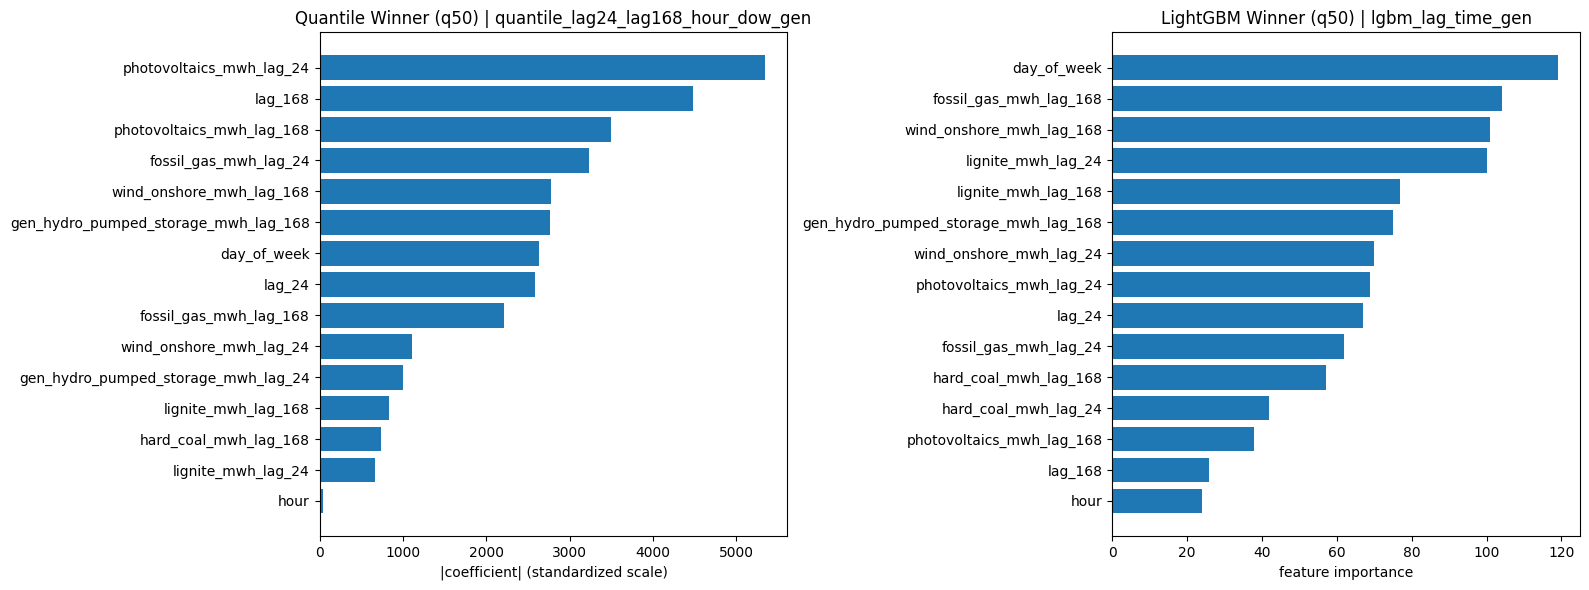

In [8]:
baseline_feature_cols = FEATURE_MAP[LOCKED_BENCHMARK_BASELINE]

baseline_test_df, baseline_test_preds, baseline_test_interval, baseline_test_models = run_quantile_test(
    feature_cols=baseline_feature_cols,
    quantile_alpha=locked_baseline_alpha,
)

tuned_lgbm_test_df, tuned_lgbm_test_preds, tuned_lgbm_test_interval, tuned_lgbm_test_models = run_lgbm_test(
    feature_cols=winner_feature_cols,
    param_overrides=tuned_best_params,
)

print("Baseline test metrics:")
print(baseline_test_df)
print("Baseline test interval metrics:", baseline_test_interval)
print()
print("Tuned winner:", winner_candidate)
print(tuned_lgbm_test_df)
print("Tuned winner test interval metrics:", tuned_lgbm_test_interval)

shap_importance_df = pd.DataFrame()
if SHAP_AVAILABLE:
    try:
        shap_X = test_df[winner_feature_cols].copy()
        if len(shap_X) > SHAP_SAMPLE_SIZE:
            shap_X = shap_X.sample(SHAP_SAMPLE_SIZE, random_state=SEED)

        explainer = shap.TreeExplainer(tuned_lgbm_test_models[Q_MED])
        shap_values = explainer.shap_values(shap_X)
        if isinstance(shap_values, list):
            shap_values = shap_values[0]

        shap_importance_df = (
            pd.DataFrame({
                "feature": shap_X.columns,
                "mean_abs_shap": np.abs(shap_values).mean(axis=0),
            })
            .sort_values("mean_abs_shap", ascending=False)
            .reset_index(drop=True)
        )
        print()
        print("Top SHAP features (q50 model):")
        print(shap_importance_df.head(10))
    except Exception as ex:
        print(f"SHAP computation skipped due to error: {ex}")
else:
    print("SHAP skipped: package not installed.")

with mlflow_run(EXPERIMENTS["tuning"], f"test_{winner_candidate}"):
    mlflow.set_tags(
        {
            "notebook": "02_model_training",
            "stage": "test_check",
            "winner_candidate": winner_candidate,
            "baseline_name": LOCKED_BENCHMARK_BASELINE,
        }
    )
    mlflow_log_params(
        {
            "test_rows": len(test_df),
            "baseline_feature_cols": ",".join(baseline_feature_cols),
            "baseline_quantile_alpha": locked_baseline_alpha,
            "winner_feature_cols": ",".join(winner_feature_cols),
            "shap_sample_size": SHAP_SAMPLE_SIZE,
        }
    )
    mlflow_log_params(tuned_best_params, prefix="winner_model_params")

    for _, row in baseline_test_df.iterrows():
        q_label = int(round(float(row["quantile"]) * 100))
        mlflow_log_metrics(
            {
                "pinball_loss": row["pinball_loss"],
                "mae": row["mae"],
                "rmse": row["rmse"],
                "r2": row["r2"],
            },
            prefix=f"baseline_test.q{q_label}",
        )

    for _, row in tuned_lgbm_test_df.iterrows():
        q_label = int(round(float(row["quantile"]) * 100))
        mlflow_log_metrics(
            {
                "pinball_loss": row["pinball_loss"],
                "mae": row["mae"],
                "rmse": row["rmse"],
                "r2": row["r2"],
            },
            prefix=f"winner_test.q{q_label}",
        )

    mlflow_log_metrics(baseline_test_interval, prefix="baseline_test_interval")
    mlflow_log_metrics(tuned_lgbm_test_interval, prefix="winner_test_interval")
    mlflow_log_dataframe(baseline_test_df, f"test_metrics_baseline_{LOCKED_BENCHMARK_BASELINE}.csv")
    mlflow_log_dataframe(tuned_lgbm_test_df, f"test_metrics_{winner_candidate}.csv")
    if not shap_importance_df.empty:
        mlflow_log_dataframe(shap_importance_df, f"shap_importance_q50_{winner_candidate}.csv")

# Simple feature-importance plots (winner quantile vs winner LightGBM)
TOP_N = 15

# Quantile winner: use absolute coefficients from q50 model
q50_quant_model = baseline_test_models[Q_MED].named_steps["model"]
quant_importance_df = (
    pd.DataFrame(
        {
            "feature": baseline_feature_cols,
            "importance": np.abs(np.asarray(q50_quant_model.coef_)),
        }
    )
    .sort_values("importance", ascending=False)
    .head(TOP_N)
)

# LightGBM winner: use built-in split importance from q50 model
q50_lgbm_model = tuned_lgbm_test_models[Q_MED]
lgbm_importance_df = (
    pd.DataFrame(
        {
            "feature": winner_feature_cols,
            "importance": np.asarray(q50_lgbm_model.feature_importances_, dtype=float),
        }
    )
    .sort_values("importance", ascending=False)
    .head(TOP_N)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(
    quant_importance_df["feature"][::-1],
    quant_importance_df["importance"][::-1],
)
axes[0].set_title(f"Quantile Winner (q50) | {LOCKED_BENCHMARK_BASELINE}")
axes[0].set_xlabel("|coefficient| (standardized scale)")

axes[1].barh(
    lgbm_importance_df["feature"][::-1],
    lgbm_importance_df["importance"][::-1],
)
axes[1].set_title(f"LightGBM Winner (q50) | {winner_candidate}")
axes[1].set_xlabel("feature importance")

plt.tight_layout()
plt.show()



## 5) Final Backtest (Winner Only) + Out-of-Time Gate + Significance


In [9]:
winner_full_fold_df, winner_full_summary = run_lgbm_backtest(
    feature_cols=winner_feature_cols,
    n_splits=BACKTEST_N_SPLITS,
    param_overrides=tuned_best_params,
    source_df=train_df,
)

winner_ref = {
    "pinball_mean": winner_full_summary["pinball_mean_mean"],
    "coverage": winner_full_summary["coverage_mean"],
    "coverage_gap": winner_full_summary["coverage_gap_mean"],
    "crossing_rate": winner_full_summary["crossing_rate_mean"],
    "r2_p50": winner_full_summary["r2_p50_mean"],
    "coverage_min": winner_full_summary.get("coverage_min", np.nan),
}

improve_pct, gate_pass = compare_to_baseline(winner_full_summary, locked_baseline_ref)

recent_n = max(1, min(OUT_OF_TIME_RECENT_SPLITS, len(winner_full_fold_df)))
winner_recent_fold_df = winner_full_fold_df.sort_values("fold").tail(recent_n).reset_index(drop=True)
winner_recent_summary = summarize_fold_metrics(winner_recent_fold_df)
recent_gate_pass = metrics_gate_pass(winner_recent_summary)

final_sig = paired_significance(winner_full_fold_df, baseline_fold_df, metric_col="pinball_mean")
sig_pass = bool(
    np.isfinite(final_sig.get("ttest_pvalue", np.nan))
    and final_sig.get("ttest_pvalue", np.nan) <= SIGNIFICANCE_ALPHA
    and final_sig.get("mean_delta_b_minus_a", -np.inf) > 0
)

promoted = (
    gate_pass
    and recent_gate_pass
    and improve_pct >= MIN_IMPROVEMENT_PCT
    and sig_pass
)

comparison = pd.DataFrame([
    {"model": LOCKED_BENCHMARK_BASELINE, **locked_baseline_ref},
    {"model": f"lightgbm_tuned_{winner_candidate}", **winner_ref},
])

print("Winner full backtest reference:")
print(winner_ref)
print()
print("Winner recent-fold summary (out-of-time check):")
print(winner_recent_summary)
print()
print("Significance vs locked baseline:")
print(final_sig)
print()
print("Benchmark comparison:")
print(comparison)
print()
print("Improvement vs locked baseline:", improve_pct)
print("Global gate pass:", gate_pass)
print("Recent-fold gate pass:", recent_gate_pass)
print("Significance pass:", sig_pass)
print("Promotion decision:", promoted)

with mlflow_run(EXPERIMENTS["tuning"], f"final_backtest_{winner_candidate}"):
    mlflow.set_tags(
        {
            "notebook": "02_model_training",
            "stage": "final_backtest",
            "winner_candidate": winner_candidate,
            "locked_baseline": LOCKED_BENCHMARK_BASELINE,
        }
    )
    mlflow_log_params(
        {
            "backtest_n_splits": BACKTEST_N_SPLITS,
            "feature_cols": ",".join(winner_feature_cols),
            "min_improvement_pct": MIN_IMPROVEMENT_PCT,
            "significance_alpha": SIGNIFICANCE_ALPHA,
            "out_of_time_recent_splits": recent_n,
        }
    )
    mlflow_log_params(tuned_best_params, prefix="model_params")
    mlflow_log_metrics(winner_full_summary, prefix="winner_cv")
    mlflow_log_metrics(winner_ref, prefix="winner_ref")
    mlflow_log_metrics(winner_recent_summary, prefix="winner_recent_cv")
    mlflow_log_metrics(locked_baseline_ref, prefix="baseline_ref")
    mlflow_log_metrics(final_sig, prefix="significance_vs_baseline")
    mlflow_log_metrics(
        {
            "improvement_vs_locked": improve_pct,
            "global_gate_pass": gate_pass,
            "recent_gate_pass": recent_gate_pass,
            "significance_pass": sig_pass,
            "promoted": promoted,
        },
        prefix="promotion",
    )

    mlflow_log_dataframe(winner_full_fold_df, f"final_backtest_folds_{winner_candidate}.csv")
    mlflow_log_dataframe(winner_recent_fold_df, f"final_backtest_recent_folds_{winner_candidate}.csv")
    mlflow_log_dataframe(comparison, f"final_comparison_{winner_candidate}.csv")
    mlflow_log_dataframe(pd.DataFrame([final_sig]), f"final_significance_{winner_candidate}.csv")


Winner full backtest reference:
{'pinball_mean': 2439.4400988421194, 'coverage': 0.7858376511226253, 'coverage_gap': -0.01416234887737482, 'crossing_rate': 0.0, 'r2_p50': 0.5022885514051456, 'coverage_min': 0.6925734024179621}

Winner recent-fold summary (out-of-time check):
{'pinball_q10_mean': 1601.9883545183766, 'pinball_q10_std': 38.87940670997921, 'pinball_q50_mean': 3414.1068723533563, 'pinball_q50_std': 22.14771080124524, 'pinball_q90_mean': 1470.306158047714, 'pinball_q90_std': 96.0993113571667, 'pinball_mean_mean': 2162.133794973149, 'pinball_mean_std': 26.45587181614428, 'mae_p50_mean': 6828.2137447067125, 'mae_p50_std': 44.29542160249048, 'rmse_p50_mean': 8611.47637326809, 'rmse_p50_std': 36.39170328445289, 'r2_p50_mean': 0.6110137095899655, 'r2_p50_std': 0.010894089871693824, 'coverage_mean': 0.817573402417962, 'coverage_std': 0.012305699481865271, 'interval_width_mean': 23560.535457822327, 'interval_width_std': 1285.2746718855033, 'coverage_gap_mean': 0.01757340241796196, 

## Notes
- This notebook now emphasizes stronger model selection confidence before promotion.
- Baseline is tuned first (features + alpha), then locked as benchmark.
- Race and tuning use larger CV, significance checks, and Optuna search.
- Final promotion requires global CV gate + recent-fold gate + statistical significance.
